## Amazon E-Commerce Product Analysis

  ### Project Goal 
=> In this project, we aim to gain actionable e-commerce insights about what drives product popularity and satisfaction using Amazon product data. Our analysis will focus on these key areas: 
- Pricing strategy
- Customer Satisfaction
- Product performance
- Customer Engagement

=> The final deliverables will include 
- Cleaned dataset, Exploratory data analysis(EDA), and Visualizations, Highlight actionable business insights

**We use reusable modules to avoid code duplication, simplify maintenance, and make programs more efficient.**

In [ ]:
# Import all functions, and libraries from the Reusable_Module module
from Amazon_Ecommerce_Project.Reusable_Module import *

In [2]:
# Calls the load_data function to read 'amazon.csv' into a pandas DataFrame
df = load_data("amazon.csv") 

In [3]:
# Call the audit_data to dispaly basic info to check shape, data types, missing values, and duplicates
audit_data(df)

DATA AUDIT REPORT
--------------------------------------------------
Rows: 1465 | Columns: 16

Column Types:
object    16
Name: count, dtype: int64

Missing Values:
rating_count    2
dtype: int64

Duplicate Rows: 0
--------------------------------------------------


{'shape': (1465, 16),
 'missing_values': {'product_id': 0,
  'product_name': 0,
  'category': 0,
  'discounted_price': 0,
  'actual_price': 0,
  'discount_percentage': 0,
  'rating': 0,
  'rating_count': 2,
  'about_product': 0,
  'user_id': 0,
  'user_name': 0,
  'review_id': 0,
  'review_title': 0,
  'review_content': 0,
  'img_link': 0,
  'product_link': 0},
 'duplicate_rows': 0}

### Initial Data Quality Check Summary

- The dataset contains 1,465 records across 16 columns
- All columns were initially read as string type, which means numeric fields such as price, discount percentage, rating, and rating count will require conversion before quantitative analysis.
- No duplicate rows were found, confirming that the dataset does not contain redundant entries in its raw form.
- The audit detected two missing values in the rating_count column, Since we only have two missing values out of 1,465 records, exclusion is usually the cleanest and safest choice.


### Drop Irrelevant Columns
Remove 5 non-essential columns( `about_product`, `review_id`, `review_title`, `img_link` and `product_link`) to streamline the dataset and focus on variables relevant for analysis.

In [4]:
df = df.drop(columns=['img_link', 'product_link','review_id','review_title','about_product'])
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'user_id', 'user_name', 'review_content'],
      dtype='object')

 ### Converting Numeric Columns & Cleaning symbols


- Numeric fields originally contained formatting symbols(currency sign, commas, and percentage signs)
  which prevented correct numerical analysis.
- A reusable cleaning function applied to strip theses symbols and safely convert all numeric
  columns into proper numerical type.

In [5]:
# Call the clean_numeric_columns to clean and convert price, discount, rating, and count columns into numeric values
numeric_cols = [
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'rating',
    'rating_count'
]

df = clean_numeric_columns(df, numeric_cols)

### Health check 
Running audit_data(df) right after cleaning is a checkpoint. It verifies that the preprocessing worked and flags any remaining issues before we move into EDA.


In [6]:

audit_data(df)

DATA AUDIT REPORT
--------------------------------------------------
Rows: 1465 | Columns: 11

Column Types:
object     6
float64    4
int64      1
Name: count, dtype: int64

Missing Values:
rating_count    2
rating          1
dtype: int64

Duplicate Rows: 68
--------------------------------------------------


{'shape': (1465, 11),
 'missing_values': {'product_id': 0,
  'product_name': 0,
  'category': 0,
  'discounted_price': 0,
  'actual_price': 0,
  'discount_percentage': 0,
  'rating': 1,
  'rating_count': 2,
  'user_id': 0,
  'user_name': 0,
  'review_content': 0},
 'duplicate_rows': 68}

### Post-Conversion Validation

After converting price and rating fields to numeric types, 1 invalid entry was detected in rating column and automatically converted to missing values (`NaN`). 

- `rating` contains 1 missing value
- `rating_count` contains 2 missing values
- 68 duplicate records were detected.


### Handling Missing Values

Since  `rating` and `rating_count` represent actual customer feedback and engagement, imputing values would introduce bias.  
Drop these rows to preserve analytical reliability.


In [7]:
df = df.dropna(subset=['rating', 'rating_count'])
df.shape

(1462, 11)

### Removing Duplicate Records

68 duplicate rows were detected in the dataset.  
Duplicates can artificially inflate product popularity and rating patterns, therefore remove duplicates to ensure reliable analysis.

In [8]:
df.duplicated().sum()

np.int64(68)

In [9]:
df = df.drop_duplicates()
df.shape

(1394, 11)

### Simplifying Category Field

The `category` column contains hierarchical paths.
For meaningful product popularity analysis, the primary category (first level) extracted into a new column `main_category`.

In [10]:
df['main_category'] = df['category'].str.split('|').str[0]
df[['category','main_category']].head()

,category,main_category
0,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories
1,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories
2,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories
3,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories
4,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories


### Clean and normalize review text
Review text was standardized by converting to lowercase, removing links and punctuation, and normalizing spacing. This preprocessing step ensures that review text is uniform, clean, and analyzable.

In [11]:
# Call the clean_review_text to standardise the text
df['clean_review'] = df['review_content'].apply(clean_review_text)
df[['review_content','clean_review']].head()

,review_content,clean_review
0,Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...
1,I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...
2,"Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdy good nice product...
3,"Good product,long wire,Charges good,Nice,I bou...",good product long wire charges good nice i bou...
4,"Bought this instead of original apple, does th...",bought this instead of original apple does the...


### Engagement Metric

Longer reviews often indicate stronger customer involvement, while shorter reviews may reflect quick feedback. By quantifying review length, we can analyze patterns in customer engagement and correlate them with ratings.

In [12]:
# Count how many words are in each review (engagement measure)
df["review_word_count"] = df["clean_review"].str.split().str.len()
df[["clean_review", "review_word_count"]].head()

,clean_review,review_word_count
0,looks durable charging is fine toono complains...,66
1,i ordered this cable to connect my phone to an...,220
2,not quite durable and sturdy good nice product...,16
3,good product long wire charges good nice i bou...,86
4,bought this instead of original apple does the...,448


### Statistical snapshot of the dataset
Making it easy to spot patterns, anomalies, and data quality issues before deeper analysis

In [13]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count,review_word_count
count,1394.000000,1394.000000,1394.000000,1394.000000,1394.000000,1394.000000
mean,3241.220803,5632.927747,47.243902,4.093185,18515.314921,255.321377
std,7081.940704,11084.162832,21.713449,0.291966,43578.644667,331.471764
min,39.000000,39.000000,0.000000,2.000000,2.000000,13.000000
25%,347.250000,899.000000,31.000000,4.000000,1183.500000,87.000000
50%,876.000000,1722.500000,50.000000,4.100000,5065.500000,149.000000
75%,2098.000000,4686.750000,63.000000,4.300000,17408.250000,257.000000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000,3096.000000


### Feature Engineering: Discount Metrics
 New features `discount_amount` was engineered to capture promotional impact. discount_amount and discount_percentage enhance the dataset by linking pricing strategies with customer behavior and product performance, enabling more meaningful analysis.


In [14]:
df['discount_amount'] = df['actual_price'] - df['discounted_price']

## Exploratory Data Analysis Overview

This analysis examines Amazon product data to understand how pricing strategy, customer engagement, and customer satisfaction influence product performance
- Pricing Strategy → Evaluates actual vs. discounted prices, discount amounts, and discount percentages to measure promotional impact.
- Customer Engagement → Assesses review length (word counts) and frequency of reviews to gauge how actively customers interact with products.
- Customer Satisfaction → Analyzes ratings quality perceptions and satisfaction trends.
- Product Performance → Links pricing and engagement patterns with ratings to highlight which strategies drive stronger outcomes.


**Relationship Between Discounts and Product Popularity:** Are higher discounts associated with higher popularity?

**Relationship Between Rating and Product Popularity:** Do higher ratings lead to higher popularity?

**Relationship Between Rating and Review:** Do longer reviews relate to lower or higher ratings?


In [15]:
df[['discount_percentage', 'rating_count']].corr()

,discount_percentage,rating_count
discount_percentage,1.000000,0.016707
rating_count,0.016707,1.000000


In [16]:
df[['rating', 'rating_count']].corr()

,rating,rating_count
rating,1.000000,0.104668
rating_count,0.104668,1.000000


In [17]:
df[['review_word_count', 'rating']].corr()

,review_word_count,rating
review_word_count,1.000000,0.079683
rating,0.079683,1.000000


### Relationship Between Discounts, Ratings, and Customer Behavior

We examined whether pricing incentives and customer feedback influence product popularity and satisfaction.
- Higher discounts are not strongly associated with higher popularity.
- Higher ratings slightly relate to product popularity, but the effect is weak.
- Longer reviews are only weakly associated with higher ratings.

**Conclusion:**
Customer engagement is not strongly driven by discounts or ratings alone.  
Popularity and satisfaction appear to depend more on product usefulness and real customer demand rather than simple pricing or review metrics.

### Visualizations
This visualization suite illustrates how pricing, engagement, and satisfaction metrics interact to shape product performance. Each chart highlights a specific analytical question:
- Do Discounts Influence Product Popularity?
- Do Longer Reviews Relate to Higher Ratings?
- How Are Product Ratings Distributed?
- Which Categories Dominate the Product Mix?
- Which categories underperform the product mix?
- Which Products Attract the Most Reviews?
- How Are Discounts Distributed Across Products?
- What Do Correlations Reveal About Key Metrics?

**1. Discount vs product popurality**
  - Does discount affect demand?

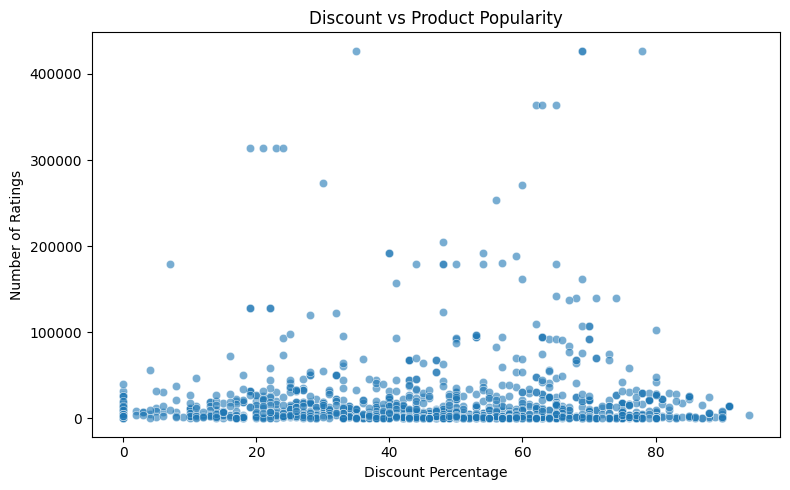

Correlation: 0.02


In [18]:
plot_scatter_with_correlation(df,
 "discount_percentage",
 "rating_count",
 "Discount vs Product Popularity",
 "Discount Percentage",
 "Number of Ratings"
)

**Key Insight:** 
- Discounts show little impact on popularity. Large price cuts don’t guarantee more ratings or engagement
- Popularity is likely driven by product relevance rather than promotions.

**2. Review length vs Rating**

- Do longer reviews relate to higher or lower ratings?

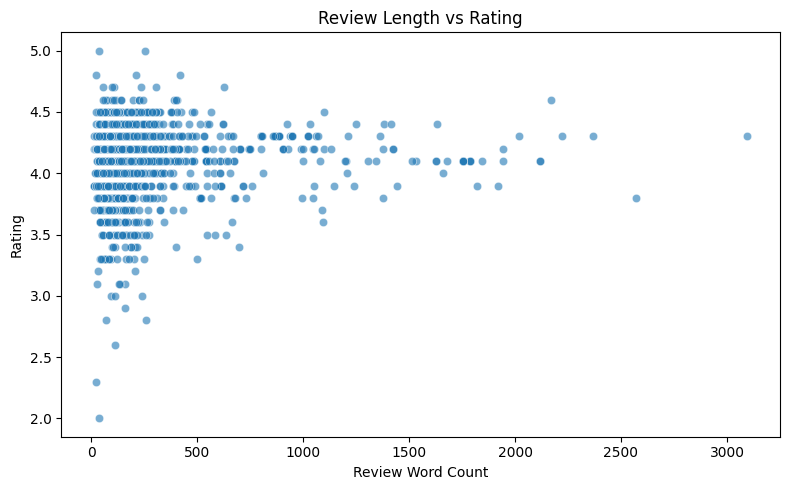

Correlation: 0.08


In [19]:
plot_scatter_with_correlation(df,
"review_word_count",
"rating",
"Review Length vs Rating",
"Review Word Count",
"Rating"
)

**Key Insight:**
- Longer reviews are not strongly associated with higher or lower ratings.
- Review length reflects customer involvement, not necessarily satisfaction.

**3.Rating Distribution**
- How Are Product Rating Distributed?

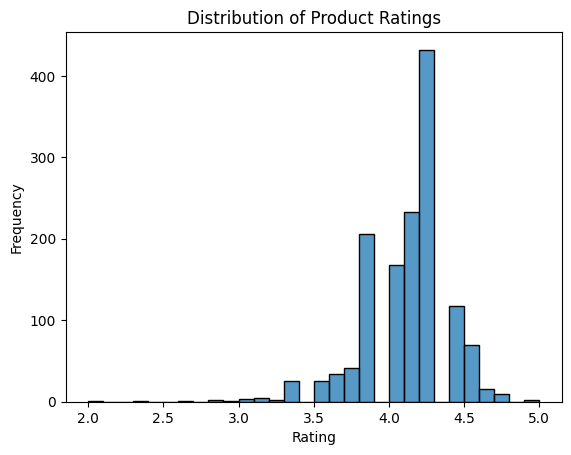

In [20]:
plot_histogram(df,"rating","Distribution of Product Ratings","Rating","Frequency")

**Key Insight:**
- Most products have high ratings.
- Very low-rated products are rare.
- Customer satisfaction overall appears positive. which shows strong product quality control

**4. Top Main Categories by Product Count**
- Which Categories Dominate the Product Mix?

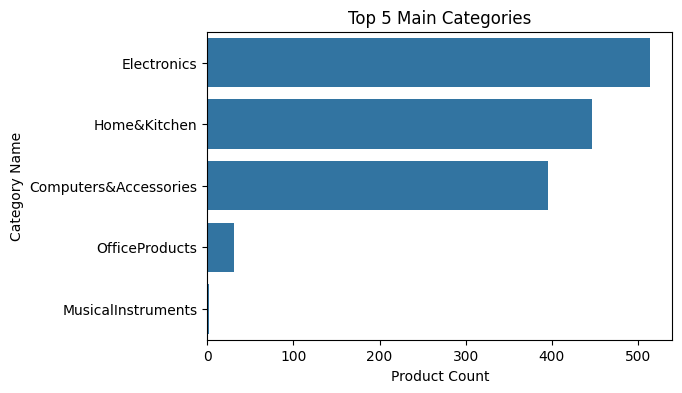

In [21]:
plot_bar(df, group_col="main_category", n=5, mode="top", xlabel="Product Count", ylabel="Category Name",title="Top 5 Main Categories")

**Key Insight:**
- Certain categories dominate the mix.
- Market competition is likely higher in dominant categories.
- Category concentration suggests tailored strategies are needed per segment.

**5. Underrepresented Categories in the Product Mix**

-Which categories underperform the product mix?

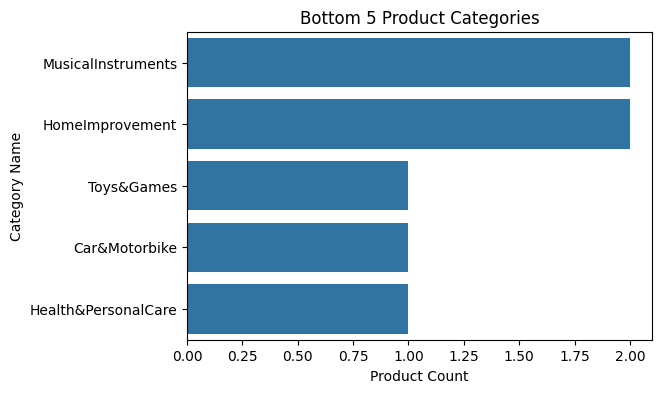

In [22]:
plot_bar(df, group_col="main_category", n=5, mode="bottom", xlabel="Product Count", ylabel="Category Name",title="Bottom 5 Product Categories")

**Key Insight:**
- Low product volume
- Lower competition
- Potential for focused growth

**6. Top 10 Most Reviewed Products**
- Which Products Attract the Most Reviews?

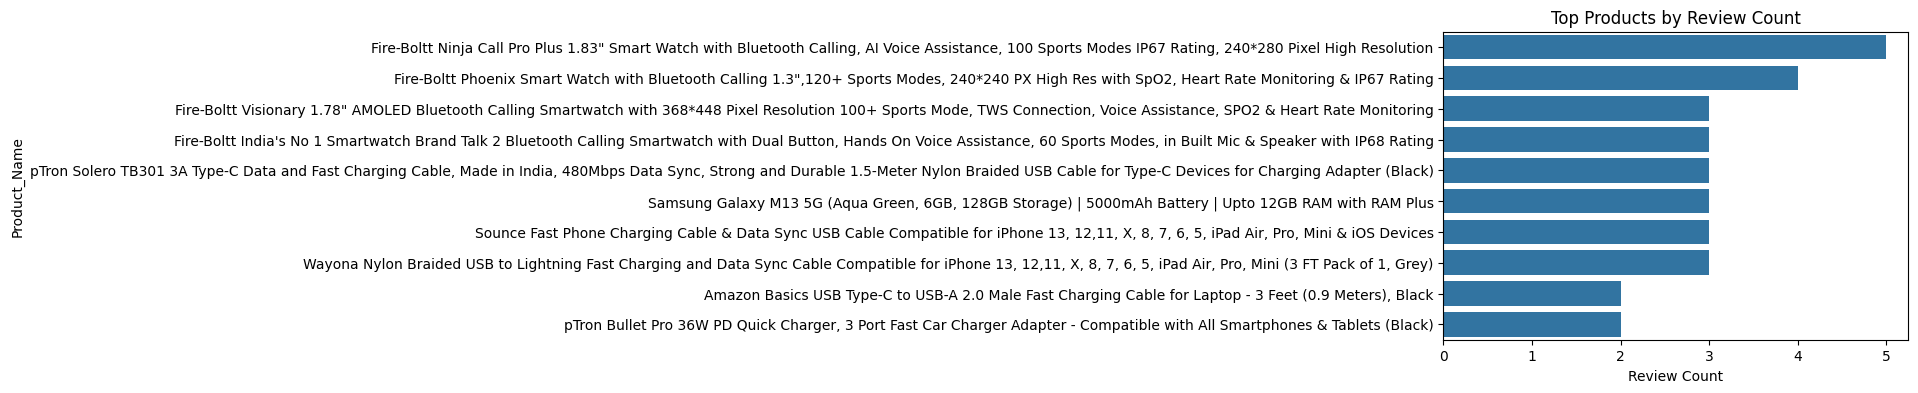

In [23]:
plot_bar(df, group_col="product_name", count_col="review_content", n=10, mode="top", title="Top Products by Review Count", xlabel="Review Count")



**Key Insight:**

- A small number of products account for the majority of reviews.
- Engagement is concentrated in a few items.
- A few products drive most customer attention, so strategic focus on high-performing items is critical

**7. Discount Percentage Distribution**
- How are discounts distributed across products?


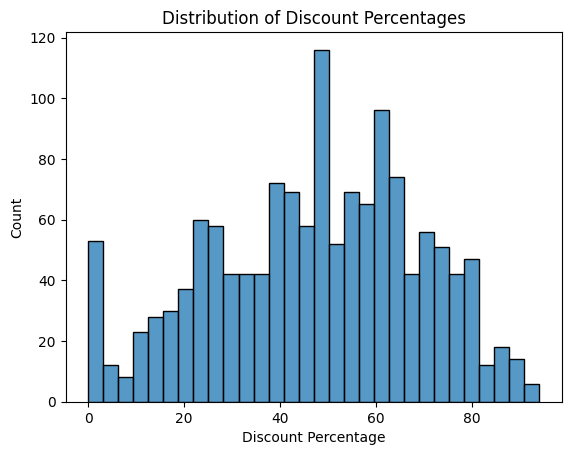

In [24]:
plot_histogram(df, 'discount_percentage', title="Distribution of Discount Percentages", x_lable="Discount Percentage", y_lable="Count")

**Key Insight:**
- Discounts cluster around moderate ranges, with fewer extreme promotions.
- Balanced discounting is common, but extreme discounts are rare and not necessarily effective.


**8. Correlation heatmap**
- What do correlations reveal about key metrics?

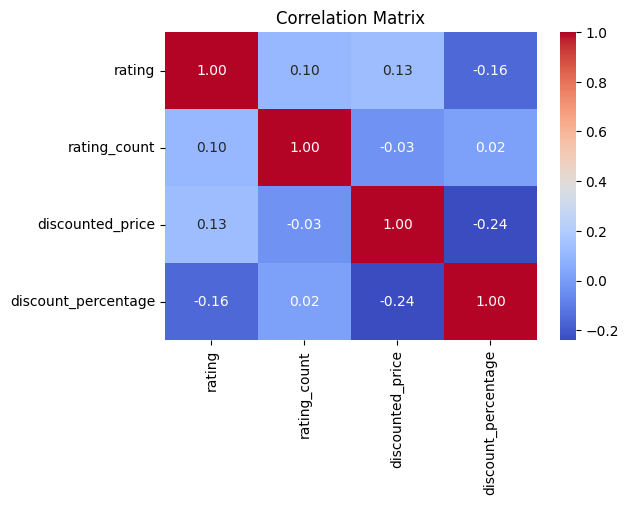

In [25]:
plot_correlation_heatmap(df,['rating', 'rating_count', 'discounted_price', 'discount_percentage'])

**Key Insight:**
- Weak correlations across discounts, ratings.
- No single metric dominates 
- product performance is multifactorial.

### Overall Summary
- Discounts don’t drive popularity — relevance and demand matter more.
- Ratings are inflated — sentiment analysis adds nuance.
- Engagement is complex — review length signals involvement, not satisfaction.
- Category structure matters — dominant categories experience higher competition, while smaller categories may present growth opportunities.
- Product engagement is highly concentrated, with a small number of products driving most review activity.
- Performance is multifactorial — no single metric explains success.